# Tomato Leaf Disease Classification on Real Data (PlantVillage)

## 1. Introduction
Farmers often detect crop diseases too late, once damage has already spread
across a field. An automated system that classifies a leaf photo as healthy
or diseased gives farmers a chance to act early. This notebook trains a
Convolutional Neural Network (CNN) on **real photographs** of tomato leaves
to distinguish three classes:

- `Tomato___healthy`
- `Tomato___Bacterial_spot`
- `Tomato___Late_blight`

**Dataset:** [PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset) —
a real, publicly published dataset of plant leaf images (Hughes & Salathé,
2015; Mohanty et al., 2016), **5,627 real photographs** across the 3 classes
above, each 256x256 RGB.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1789033600.751938     713 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789033600.869891     713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789033602.276439     713 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Build a file index from the real image folders

In [2]:
DATA_DIR = "plantvillage_data"
CLASS_NAMES = sorted(os.listdir(DATA_DIR))
print(f"Classes found: {CLASS_NAMES}")

records = []
for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)
    for fname in os.listdir(class_dir):
        records.append({"filepath": os.path.join(class_dir, fname), "label": class_name})

file_df = pd.DataFrame(records)
print(f"Total images: {len(file_df)}")
file_df["label"].value_counts()

Classes found: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___healthy']
Total images: 5627


label
Tomato___Bacterial_spot    2127
Tomato___Late_blight       1909
Tomato___healthy           1591
Name: count, dtype: int64

## 3. Preview real sample images from each class

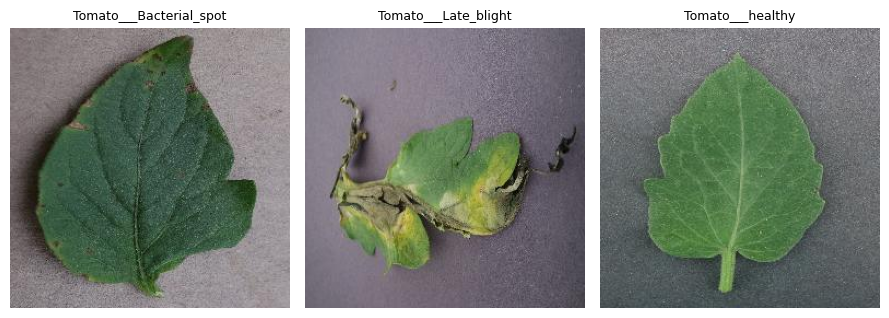

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for ax, class_name in zip(axes, CLASS_NAMES):
    sample_path = file_df[file_df.label == class_name].filepath.iloc[0]
    img = tf.keras.utils.load_img(sample_path)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")
fig.tight_layout()
fig.savefig("sample_leaves.png", dpi=150)
plt.show()

## 4. Train / validation / test split (stratified, on real files)

In [4]:
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
file_df["label_idx"] = file_df["label"].map(label_to_idx)

train_df, temp_df = train_test_split(file_df, test_size=0.3, random_state=42, stratify=file_df["label_idx"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label_idx"])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
print("\nClass balance check (train set):")
print(train_df["label"].value_counts(normalize=True))

Train: 3938 | Validation: 844 | Test: 845

Class balance check (train set):
label
Tomato___Bacterial_spot    0.378111
Tomato___Late_blight       0.339259
Tomato___healthy           0.282631
Name: proportion, dtype: float64


## 5. Load images into memory

With 5,627 images this fits comfortably in memory, and loading once up front
(instead of decoding JPEGs from disk on every training epoch) makes training
substantially faster - a reasonable engineering trade-off at this dataset
size. For a much larger dataset, a streaming `tf.data` pipeline reading from
disk per batch would be the better choice instead.

In [5]:
IMG_SIZE = 80

def load_images(df):
    images = []
    for path in df["filepath"]:
        img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        images.append(tf.keras.utils.img_to_array(img) / 255.0)
    return np.stack(images), df["label_idx"].values

X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

X_train: (3938, 80, 80, 3) | X_val: (844, 80, 80, 3) | X_test: (845, 80, 80, 3)


## 6. Data augmentation

Real field photos vary in leaf orientation and framing, so we apply random
flips, rotation, and zoom during training only.

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

## 7. Build the CNN

In [7]:
def build_cnn(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


model = build_cnn((IMG_SIZE, IMG_SIZE, 3), len(CLASS_NAMES))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,179 (1.78 MB)

 Trainable params: 466,179 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/12


62/62 - 21s - 337ms/step - accuracy: 0.6498 - loss: 0.7226 - val_accuracy: 0.8246 - val_loss: 0.4457


Epoch 2/12


62/62 - 20s - 315ms/step - accuracy: 0.8865 - loss: 0.3065 - val_accuracy: 0.8412 - val_loss: 0.4317


Epoch 3/12


62/62 - 20s - 323ms/step - accuracy: 0.9340 - loss: 0.1944 - val_accuracy: 0.7832 - val_loss: 0.5834


Epoch 4/12


62/62 - 18s - 287ms/step - accuracy: 0.9441 - loss: 0.1562 - val_accuracy: 0.7844 - val_loss: 0.6392


Epoch 5/12


62/62 - 20s - 330ms/step - accuracy: 0.9497 - loss: 0.1426 - val_accuracy: 0.8555 - val_loss: 0.4361


## 9. Training curves

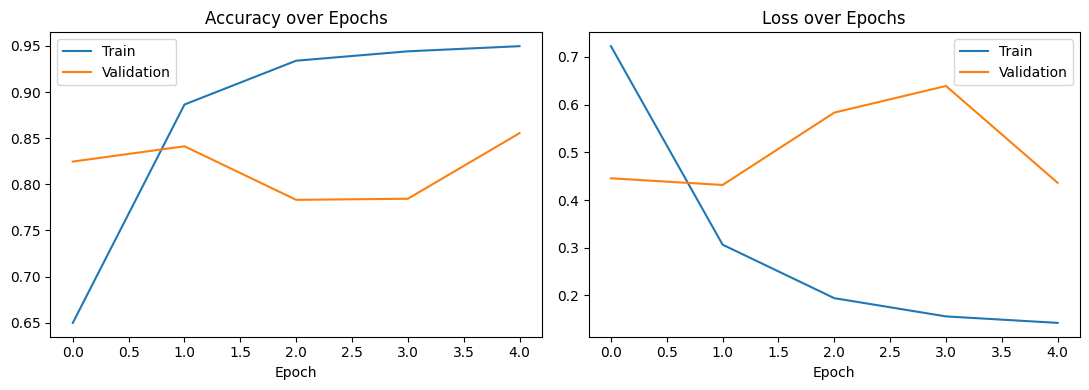

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

fig.tight_layout()
fig.savefig("training_curves.png", dpi=150)
plt.show()

## 10. Evaluate on the held-out real test set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test accuracy: 0.857
Test loss: 0.411



Classification report:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot       0.96      0.87      0.91       319
   Tomato___Late_blight       0.89      0.73      0.80       287
       Tomato___healthy       0.74      1.00      0.85       239

               accuracy                           0.86       845
              macro avg       0.86      0.86      0.85       845
           weighted avg       0.87      0.86      0.86       845



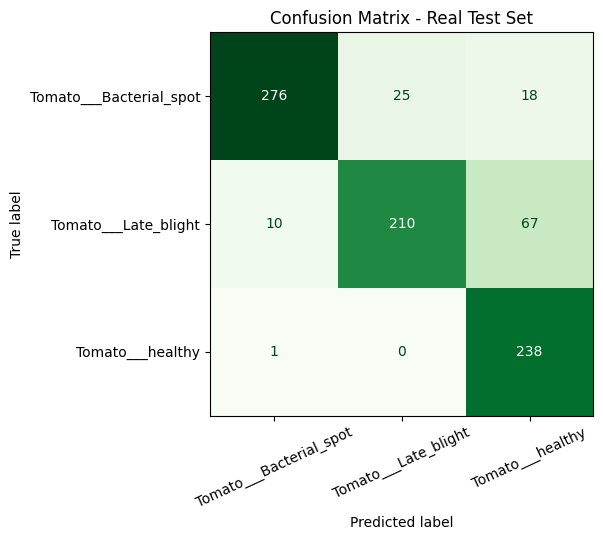

In [11]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=25)
ax.set_title("Confusion Matrix - Real Test Set")
fig.tight_layout()
fig.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 11. Inspect real predictions

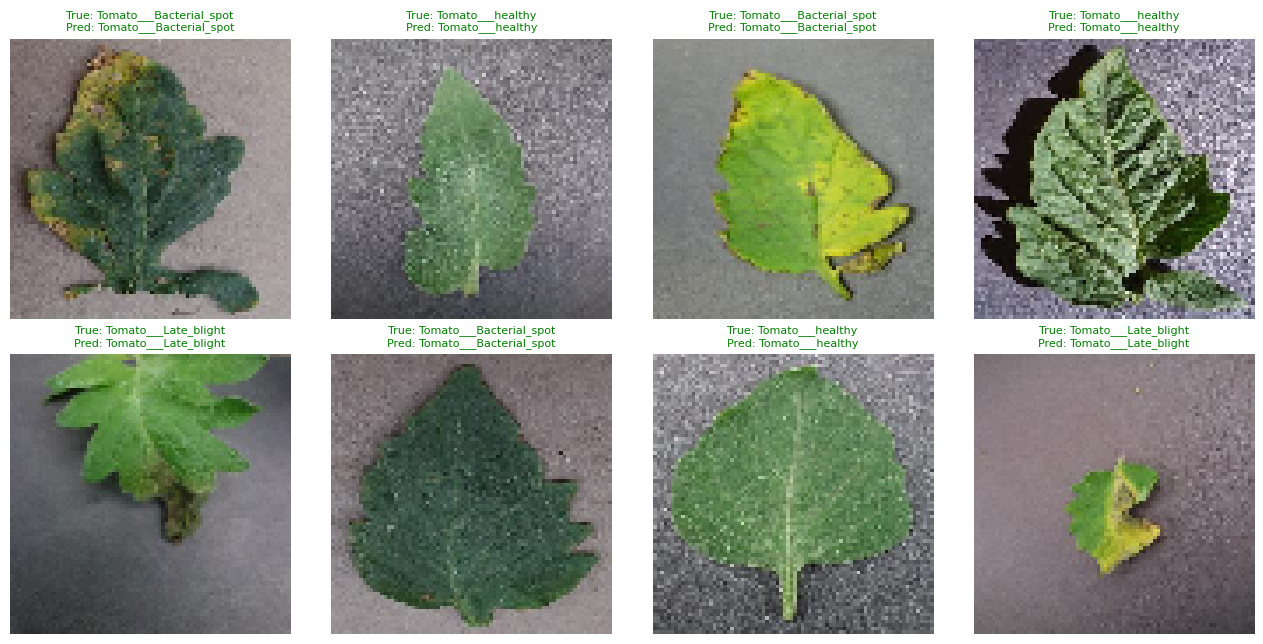

In [12]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, idx in zip(axes.flatten(), sample_idx):
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.imshow(X_test[idx])
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    ax.axis("off")

fig.tight_layout()
fig.savefig("sample_predictions.png", dpi=150)
plt.show()

## 12. Conclusion

In [13]:
print("=" * 60)
print("Tomato Leaf Disease Classification (Real PlantVillage Data) - Summary")
print("=" * 60)
print(f"Classes            : {CLASS_NAMES}")
print(f"Total real images  : {len(file_df)}")
print(f"Training images    : {len(train_df)}")
print(f"Test accuracy      : {test_acc:.3f}")
print("Saved: sample_leaves.png, training_curves.png, confusion_matrix.png, sample_predictions.png")

Tomato Leaf Disease Classification (Real PlantVillage Data) - Summary
Classes            : ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___healthy']
Total real images  : 5627
Training images    : 3938
Test accuracy      : 0.857
Saved: sample_leaves.png, training_curves.png, confusion_matrix.png, sample_predictions.png


**Note on scope:** this notebook uses 3 of the 38 classes in the full
PlantVillage dataset (all Tomato-related, to keep training time practical on
a CPU). The same pipeline extends directly to all 38 classes / 14 crop
species by pointing `DATA_DIR` at the full dataset - no code changes needed,
just more compute time.